# 02 - Model Experiments
Runs all models against the same dataset and logs results to MLflow.
All preprocessing imported from 01_preprocessing.ipynb via %run.

| Notebook | Purpose |
|----------|---------|
| 00_EDA | Explore dataset |
| 01_preprocessing | Prepare model variants |
| 02_experiments | Train, evaluate, compare (here) |

## Imports

In [40]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
import mlflow
import mlflow.xgboost
from sklearn.metrics import mean_squared_error, mean_absolute_error
from dotenv import load_dotenv
import warnings
warnings.filterwarnings('ignore')
load_dotenv()

PROJECT_PATH = os.getenv('PROJECT_PATH')
DATA_PATH = os.getenv('DATA_PATH')
EXPORTS_PATH = os.getenv('EXPORTS_PATH')


mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("ts-model-framework")

print(f"Project path: {PROJECT_PATH}")
print(f"Data path: {DATA_PATH}")
print(f"Data path: {EXPORTS_PATH}")

print("Libraries loaded.")
print(f"MLflow tracking: http://localhost:5000")

Project path: Q:\scripts\projects\ts-model-framework
Data path: Q:\scripts\projects\ts-model-framework\data
Data path: Q:\scripts\projects\ts-model-framework\exports
Libraries loaded.
MLflow tracking: http://localhost:5000


---
## S1 - Load Preprocessed Data
Runs 01_preprocessing.ipynb and inherits all prepared datasets.

In [41]:
%run {os.getenv('PREPROCESSING_SCRIPT')}

Project path: Q:\scripts\projects\ts-model-framework
Data path: Q:\scripts\projects\ts-model-framework\data
Data path: Q:\scripts\projects\ts-model-framework\exports
Libraries loaded.
Core dataset loaded: (452, 24)
Date range: 2013-01-02 00:00:00 to 2014-03-31 00:00:00
Train: (363, 24) | 2013-01-02 00:00:00 to 2013-12-31 00:00:00
Test:  (89, 24)  | 2014-01-02 00:00:00 to 2014-03-31 00:00:00
XGBoost train: (333, 23) | test: (89, 23)
SARIMAX train: (363,) | test: (89,)
Exog columns: ['dcoilwtico', 'is_national_holiday', 'is_regional_holiday', 'is_local_holiday']
Prophet train: (363, 2) | test: (89, 2)
          ds      y
0 2013-01-02  582.0
1 2013-01-03  310.0
2 2013-01-04  338.0
LSTM train shape: (333, 30, 1) | test shape: (59, 30, 1)
Scaler range: 4.00 to 1090.00


In [17]:
%run Q:/scripts/projects/ts-model-framework/exports/01_preprocessing.py

Data path: Q:\scripts\projects\ts-model-framework\data
Libraries loaded.
Core dataset loaded: (452, 24)
Date range: 2013-01-02 00:00:00 to 2014-03-31 00:00:00
Train: (363, 24) | 2013-01-02 00:00:00 to 2013-12-31 00:00:00
Test:  (89, 24)  | 2014-01-02 00:00:00 to 2014-03-31 00:00:00
XGBoost train: (333, 23) | test: (89, 23)
SARIMAX train: (363,) | test: (89,)
Exog columns: ['dcoilwtico', 'is_national_holiday', 'is_regional_holiday', 'is_local_holiday']
Prophet train: (363, 2) | test: (89, 2)
          ds      y
0 2013-01-02  582.0
1 2013-01-03  310.0
2 2013-01-04  338.0
LSTM train shape: (333, 30, 1) | test shape: (59, 30, 1)
Scaler range: 4.00 to 1090.00


---
## S2 - Shared Evaluation Function
Single function used by ALL models for consistent metric calculation.

In [44]:
def evaluate(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2   = 1 - (np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2))

    print(f"\n{model_name}")
    print(f"  RMSE: {rmse:.2f} | MAE: {mae:.2f} | MAPE: {mape:.2f}% | R²: {r2:.4f}")

    return {"rmse": rmse, "mae": mae, "mape": mape, "r2": r2}

---
## S3 - XGBoost Baseline
No hyperparameter tuning -- default parameters only.
Goal: establish a reproducible baseline before any optimization.

In [45]:
xgb_params = {
    "n_estimators": 1000,
    "early_stopping_rounds": 50
}

with mlflow.start_run(run_name="xgboost-baseline"):
    model_xgb = xgb.XGBRegressor(**xgb_params)
    model_xgb.fit(X_train, y_train,
                  eval_set=[(X_test, y_test)],
                  verbose=False)

    preds_xgb = model_xgb.predict(X_test)
    metrics   = evaluate(y_test, preds_xgb, "XGBoost Baseline")

    mlflow.log_params(xgb_params)
    mlflow.log_metrics(metrics)
    mlflow.xgboost.log_model(model_xgb, "model")

2026/04/27 20:27:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



XGBoost Baseline
  RMSE: 146.68 | MAE: 102.65 | MAPE: 23.65% | R²: 0.3675
🏃 View run xgboost-baseline at: http://localhost:5000/#/experiments/2/runs/5801cb80a7134dd886a947bcd0bbc743
🧪 View experiment at: http://localhost:5000/#/experiments/2


---
## S4 - SARIMAX Baseline

In [8]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarimax_order        = (1, 0, 1)
sarimax_seasonal     = (1, 0, 0, 7)

with mlflow.start_run(run_name="sarimax-baseline"):
    model_sarimax = SARIMAX(
        y_sarimax_train,
        exog=exog_train,
        order=sarimax_order,
        seasonal_order=sarimax_seasonal
    ).fit(disp=False)

    preds_sarimax = model_sarimax.forecast(
        steps=len(y_sarimax_test),
        exog=exog_test
    )
    metrics = evaluate(y_sarimax_test.values, preds_sarimax.values, "SARIMAX Baseline")

    mlflow.log_params({"order": str(sarimax_order), "seasonal_order": str(sarimax_seasonal)})
    mlflow.log_metrics(metrics)

q:\scripts\projects\ts-model-framework\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
q:\scripts\projects\ts-model-framework\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
q:\scripts\projects\ts-model-framework\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
q:\scripts\projects\ts-model-framework\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index begin


SARIMAX Baseline
  RMSE: 190.13 | MAE: 145.65 | MAPE: 33.56% | R²: -0.0628
🏃 View run sarimax-baseline at: http://localhost:5000/#/experiments/2/runs/617246fc63f24a94860bcb6b2828ed59
🧪 View experiment at: http://localhost:5000/#/experiments/2


---
## S5 - Prophet Baseline

In [9]:
from prophet import Prophet

with mlflow.start_run(run_name="prophet-baseline"):
    model_prophet = Prophet()
    model_prophet.fit(prophet_train)

    future   = model_prophet.make_future_dataframe(periods=len(prophet_test))
    forecast  = model_prophet.predict(future)
    preds_prophet = forecast['yhat'].tail(len(prophet_test)).values

    metrics = evaluate(prophet_test['y'].values, preds_prophet, "Prophet Baseline")

    mlflow.log_params({"model": "prophet-basic"})
    mlflow.log_metrics(metrics)

Importing plotly failed. Interactive plots will not work.
20:00:26 - cmdstanpy - INFO - Chain [1] start processing
20:00:26 - cmdstanpy - INFO - Chain [1] done processing



Prophet Baseline
  RMSE: 214.17 | MAE: 165.25 | MAPE: 37.46% | R²: -0.3484
🏃 View run prophet-baseline at: http://localhost:5000/#/experiments/2/runs/1607a3f984ae4d5aad82eea7eb4142c8
🧪 View experiment at: http://localhost:5000/#/experiments/2


---
## S6 - Results Summary
Compares all logged runs from this experiment in a single table.

In [10]:
runs = mlflow.search_runs(experiment_names=["ts-model-framework"])

summary = runs[["tags.mlflow.runName", "metrics.rmse", "metrics.mae", 
                "metrics.mape", "metrics.r2"]].rename(
    columns={"tags.mlflow.runName": "model"}
).sort_values("metrics.rmse")

print(summary.to_string(index=False))

           model  metrics.rmse  metrics.mae  metrics.mape  metrics.r2
xgboost-baseline    146.676333   102.652565     23.646052    0.367522
sarimax-baseline    190.132797   145.646837     33.561755   -0.062770
prophet-baseline    214.166547   165.252637     37.460958   -0.348430


---
## S7 - Visual Comparison

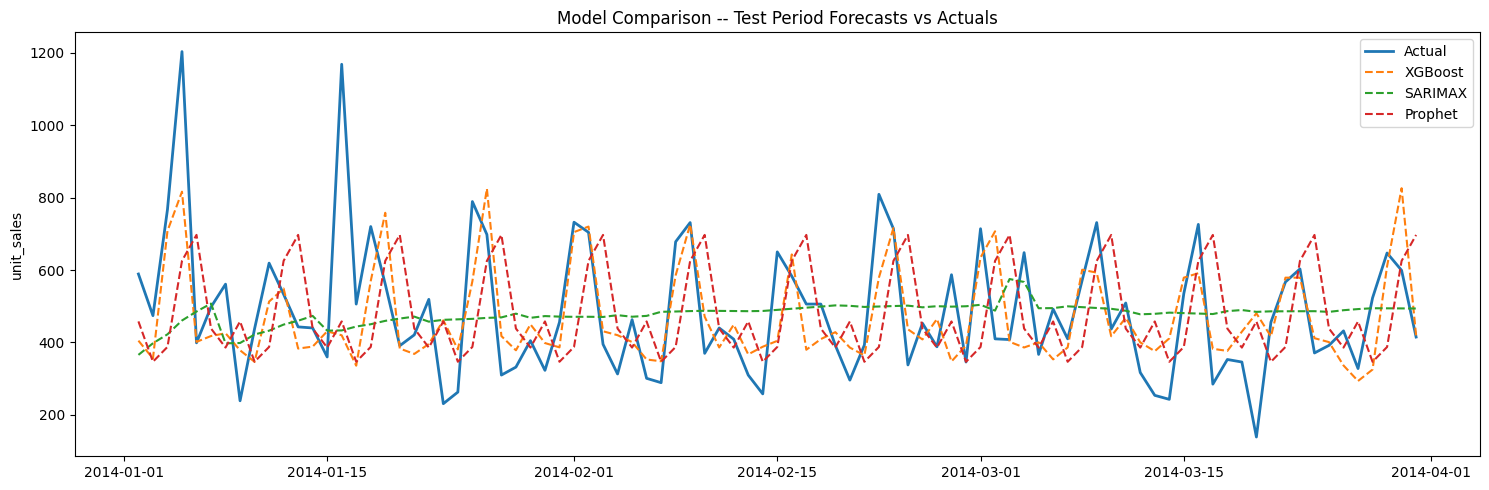

In [11]:
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(y_test.index, y_test.values, label='Actual', linewidth=2)
ax.plot(y_test.index, preds_xgb, label='XGBoost', linestyle='--')
ax.plot(y_sarimax_test.index, preds_sarimax, label='SARIMAX', linestyle='--')
ax.plot(prophet_test['ds'].values[-len(preds_prophet):], 
        preds_prophet, label='Prophet', linestyle='--')

ax.set_title('Model Comparison -- Test Period Forecasts vs Actuals')
ax.set_ylabel(TARGET_COLUMN)
ax.legend()
plt.tight_layout()
plt.show()

---
## S8 - Notes & Observations
Document findings per experiment run.

- Best model this run:
- Notable differences between models:
- Features that helped/hurt:
- Next experiment to try: